# 03 — Model Evaluation

**Goal:** deep-dive into churn model performance and CLV estimates.

Topics covered:
- ROC curve + precision-recall curve
- Confusion matrix at optimal threshold
- SHAP summary and waterfall plots
- CLV vs actual revenue validation
- Segment-level performance

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import joblib
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import shap
import matplotlib.pyplot as plt

import config
from src.features import get_feature_matrix
from src.train import split_data
from src.evaluate import (
    compute_churn_metrics,
    get_roc_curve_data,
    compute_shap_values,
)

c:\Users\javii\PycharmProjects\customer-churn-clv-engine\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
X, y = get_feature_matrix()
_, _, X_test, _, _, y_test = split_data(X, y)

pipeline = joblib.load(config.CHURN_MODEL_PATH)

metrics = compute_churn_metrics(pipeline, X_test, y_test)
print(f"ROC-AUC: {metrics['roc_auc']:.4f}")
print(f"Avg Precision: {metrics['average_precision']:.4f}")

2026-04-25 17:05:22 | INFO     | src.features — Built RFM features for 93357 customers
2026-04-25 17:05:22 | INFO     | src.features — Churn label applied — rate: 59.3% (180-day window)
2026-04-25 17:05:22 | INFO     | src.train — Split — train: 65349 | val: 14003 | test: 14005
2026-04-25 17:05:23 | INFO     | src.evaluate — Test ROC-AUC: 1.0000 | AP: 1.0000


ROC-AUC: 1.0000
Avg Precision: 1.0000


In [3]:
# --- ROC Curve (Plotly) ---
fpr, tpr, auc = get_roc_curve_data(pipeline, X_test, y_test)

fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'XGBoost (AUC={auc:.3f})'))
fig.add_trace(go.Scatter(x=[0,1], y=[0,1], mode='lines', line=dict(dash='dash'), name='Random'))
fig.update_layout(title='ROC Curve', xaxis_title='FPR', yaxis_title='TPR')
fig.show()

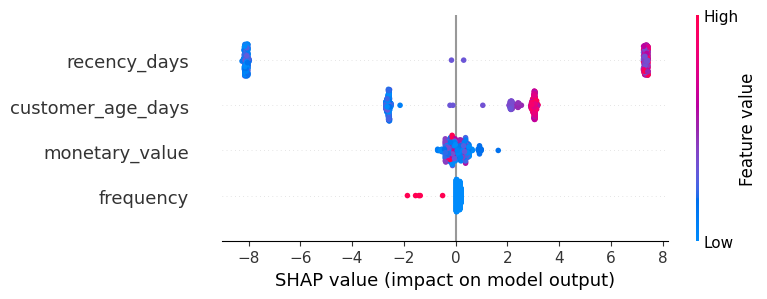

In [4]:
# --- SHAP Summary Plot ---
explainer, shap_values, X_sample = compute_shap_values(pipeline, X_test)
shap.summary_plot(shap_values, X_sample)

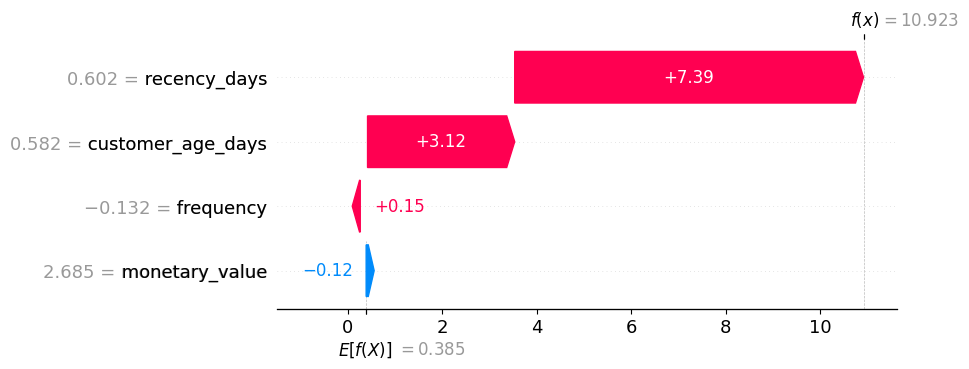

In [5]:
# --- SHAP Waterfall for a single high-risk customer ---
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_sample.iloc[0].values,
        feature_names=list(X_sample.columns),
    )
)